# Singular Value Decomposition SVD

Singular Value Decomposition (SVD) is a fundamental matrix factorization technique with wide-ranging applications in machine learning and data science. Here's a breakdown of its key aspects:  

What is SVD?

    SVD decomposes a matrix into three other matrices:
        U: A unitary matrix (left singular vectors).   

Σ (Sigma): A diagonal matrix with non-negative real numbers on the diagonal (singular values).  

        Vᵀ (V transpose): A unitary matrix (right singular vectors).
    Essentially, it breaks down a matrix into its constituent parts, revealing underlying patterns and structures.

Applications of SVD in Machine Learning:

    Dimensionality Reduction:
        SVD is used to reduce the number of features in high-dimensional datasets while preserving essential information.   

This is crucial for mitigating the "curse of dimensionality" and improving the efficiency of machine learning algorithms.  

Principal Component Analysis (PCA):

    SVD is the mathematical foundation of PCA.   

PCA uses SVD to identify the principal components of a dataset, which are orthogonal directions that capture the most variance.  

Recommendation Systems:

    SVD is used in collaborative filtering to predict user preferences.   

For example, it can analyze user-item rating matrices to identify latent factors that influence user ratings.  

Image Compression:

    SVD can be used to compress images by approximating them with lower-rank matrices.   

This reduces the storage space required for images while maintaining reasonable image quality.  

Latent Semantic Analysis (LSA):

    In natural language processing (NLP), SVD is used in LSA to identify relationships between terms and documents.   

This helps in tasks like document retrieval and topic modeling.  

Noise Reduction:

    SVD can help to filter out noise from data, by removing smaller singular values that correspond to less important information.   



In [2]:
import pandas as pd
import numpy  as np


#create simple value dataset

c_names =['post1','post2','post3','post4']

words =['ice', 'snow', 'tahoe' ,'ghost' , 'puck']

post_words =pd.DataFrame([[4,4,6,3],
                         [6,1,0,5],
                         [3,0,0,5],
                         [0,6,5,1],
                         [0,4,5,0]] ,index=words , columns=c_names)

post_words.index.names= ['word:']

post_words

,post1,post2,post3,post4
word:,,,,
ice,4,4,6,3
snow,6,1,0,5
tahoe,3,0,0,5
ghost,0,6,5,1
puck,0,4,5,0


In [3]:
#calculate U, sigma, V

U,sigma,V = np.linalg.svd(post_words)

print(np.round(V,decimals=2))

[[-0.4  -0.55 -0.61 -0.4 ]
 [-0.58  0.37  0.44 -0.58]
 [ 0.56 -0.46  0.41 -0.55]
 [-0.42 -0.59  0.52  0.45]]


In [4]:
sigma

array([13.55940373,  9.25515187,  2.06889804,  1.48472053])

In [7]:
A_approx =np.matrix(U[:,:2]) * np.diag(sigma[:2]) *np.matrix(V[:2, :])

print(pd.DataFrame( A_approx,index=words, columns= c_names ))

          post1     post2     post3     post4
ice    3.501303  4.788264  5.303188  3.479141
snow   5.534524  0.532173  0.412075  5.484183
tahoe  4.012803  0.069590 -0.059468  3.975616
ghost  0.507972  5.117862  5.779698  0.514380
puck  -0.008175  4.232570  4.794681  0.001110


In [8]:
print(post_words - A_approx)

          post1     post2     post3     post4
word:                                        
ice    0.498697 -0.788264  0.696812 -0.479141
snow   0.465476  0.467827 -0.412075 -0.484183
tahoe -1.012803 -0.069590  0.059468  1.024384
ghost -0.507972  0.882138 -0.779698  0.485620
puck   0.008175 -0.232570  0.205319 -0.001110


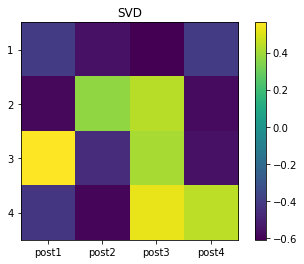

In [11]:
#plot colorbar

import matplotlib.pyplot as plt

plt.imshow(V,interpolation='none')
plt.xticks(range(len(c_names)))

plt.yticks(range(len(words)))


plt.ylim([len(words) -1.5,-.5])

ax=plt.gca()

ax.set_xticklabels(c_names)
ax.set_yticklabels(range(1, len(words) +1))

plt.title("SVD")
plt.colorbar()

In [12]:
pd.DataFrame(U[:,1] ,index=words)

,0
ice,0.001447
snow,-0.651258
tahoe,-0.501568
ghost,0.411023
puck,0.394145
